In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [2]:
# 1. Load the datasets
churn_df = pd.read_excel('Preduction_Data.xlsx', sheet_name='vw_ChurnData')
join_df = pd.read_excel('Preduction_Data.xlsx', sheet_name='vw_JoinData')


In [3]:

# 2. Data Preprocessing
# Drop identifiers and columns that wouldn't be known before a customer churns
drop_cols = ['Customer_ID', 'Churn_Category', 'Churn_Reason', 'Customer_Status']
X = churn_df.drop(columns=drop_cols)

# Convert target variable: 'Stayed' -> 0, 'Churned' -> 1
y = churn_df['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Handle missing values by filling with 'None' for categorical features
X['Value_Deal'] = X['Value_Deal'].fillna('None')
X['Internet_Type'] = X['Internet_Type'].fillna('None')



In [4]:
# 3. Encoding Categorical Variables
# Convert text columns into numbers (One-Hot Encoding)
cat_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)



In [5]:
# 4. Split Data
# 80% for training, 20% for testing the model
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)



In [6]:
# 5. Train the Model
# Using Random Forest - good for handling complex data relationships
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
# 6. Evaluate Model
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))



Accuracy: 0.8453
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       855
           1       0.82      0.60      0.69       347

    accuracy                           0.85      1202
   macro avg       0.83      0.77      0.79      1202
weighted avg       0.84      0.85      0.84      1202



In [8]:
# 7. Predict on New Data (Join Data)
# Prepare the Join dataset to match the training data format
X_join = join_df.drop(columns=drop_cols)
X_join['Value_Deal'] = X_join['Value_Deal'].fillna('None')
X_join['Internet_Type'] = X_join['Internet_Type'].fillna('None')
X_join_encoded = pd.get_dummies(X_join, columns=cat_cols, drop_first=True)

# Align columns (ensure join data has same columns as training data)
X_join_encoded = X_join_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# Make predictions and calculate churn probability
join_df['Predicted_Churn'] = rf_model.predict(X_join_encoded)
join_df['Churn_Probability'] = rf_model.predict_proba(X_join_encoded)[:, 1]



In [9]:
# 8. Export Results
# Save the results with predictions for the new customers
join_df.to_excel('Predicted_Join_Churn.xlsx', index=False)
print("Predictions saved to Predicted_Join_Churn.xlsx")

Predictions saved to Predicted_Join_Churn.xlsx


In [10]:
import joblib
# Assuming 'rf_model' is your trained model and 'encoders' is a dict of LabelEncoders
joblib.dump(rf_model, 'churn_model.pkl')
for col, le in X_encoded.items():
    joblib.dump(le, f'{col}_encoder.pkl')

In [11]:
print(len(rf_model.feature_importances_))
print(rf_model.feature_names_in_)


56
['Age' 'Number_of_Referrals' 'Tenure_in_Months' 'Monthly_Charge'
 'Total_Charges' 'Total_Refunds' 'Total_Extra_Data_Charges'
 'Total_Long_Distance_Charges' 'Total_Revenue' 'Gender_Male' 'Married_Yes'
 'State_Assam' 'State_Bihar' 'State_Chhattisgarh' 'State_Delhi'
 'State_Gujarat' 'State_Haryana' 'State_Jammu & Kashmir' 'State_Jharkhand'
 'State_Karnataka' 'State_Kerala' 'State_Madhya Pradesh'
 'State_Maharashtra' 'State_Odisha' 'State_Puducherry' 'State_Punjab'
 'State_Rajasthan' 'State_Tamil Nadu' 'State_Telangana'
 'State_Uttar Pradesh' 'State_Uttarakhand' 'State_West Bengal'
 'Value_Deal_Deal 2' 'Value_Deal_Deal 3' 'Value_Deal_Deal 4'
 'Value_Deal_Deal 5' 'Value_Deal_None' 'Phone_Service_Yes'
 'Multiple_Lines_Yes' 'Internet_Service_Yes' 'Internet_Type_DSL'
 'Internet_Type_Fiber Optic' 'Internet_Type_None' 'Online_Security_Yes'
 'Online_Backup_Yes' 'Device_Protection_Plan_Yes' 'Premium_Support_Yes'
 'Streaming_TV_Yes' 'Streaming_Movies_Yes' 'Streaming_Music_Yes'
 'Unlimited_Data_Y

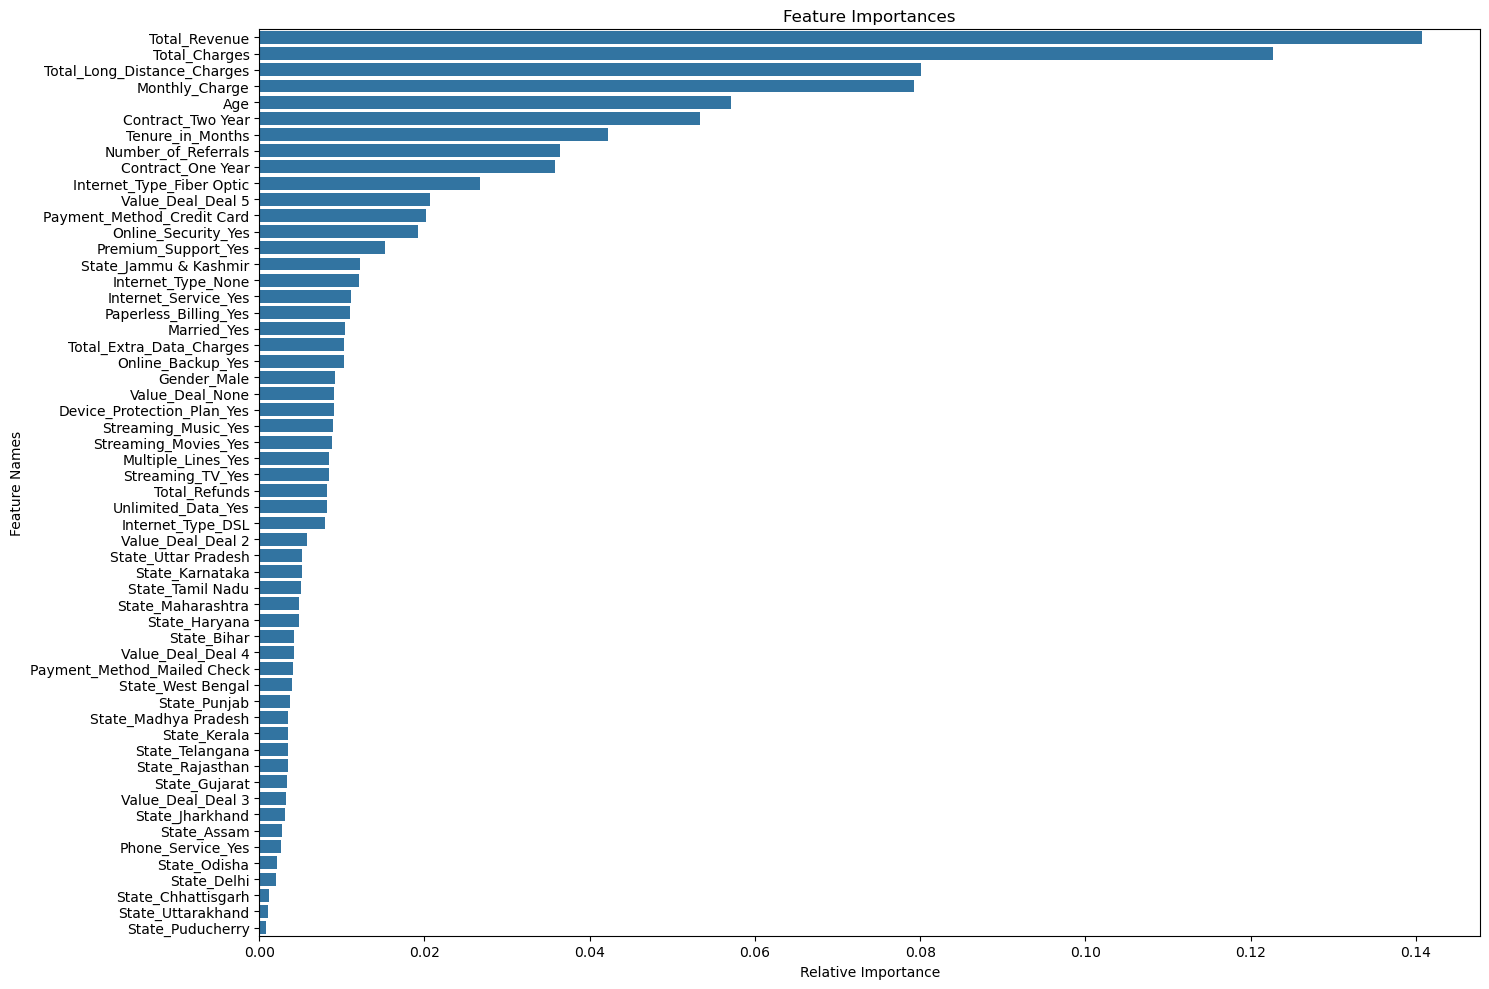

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get importances and feature names DIRECTLY from the model
importances = rf_model.feature_importances_
feature_names = rf_model.feature_names_in_

# Sort indices by importance (descending)
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(15, 10))
sns.barplot(
    x=importances[indices],
    y=feature_names[indices]
)
plt.title("Feature Importances")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Names")
plt.tight_layout()
plt.show()
